# Stage 3 — Compare against Noam's cycle-detection method

Two independent approaches to the same problem (find movement cycles in a
hand-relative-to-root signal, then describe each cycle):

- **Ours**: Hilbert phase on hand-Y-relative-to-root → cycle boundaries at
  phase = k·2π → local 3-D PCA plane per cycle (`fit_pca_phase_coordinates`,
  already run for all 58 runs x 2 hands in Stage 2, cached).
- **Noam's**: Savitzky-Golay smoothing → peak/trough detection (skill- and
  hand-specific thresholds) on the same signal → cycles between consecutive
  events (`extract_cycles_from_signal`, from `Labeled_data_analyses.ipynb`
  Section 5, reused verbatim below).

**3.1** checks whether the two methods agree on *where* cycles are and
whether our phase estimate itself behaved well. **3.2** compares cycle-level
statistics and mean-cycle shape for the 6 primary (longest-per-condition)
blocks. Nothing is refit — this notebook only reads Stage 2's cache.

In [17]:
import sys, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks

sys.path.insert(0, str(Path.cwd()))
import _loading as L
import _plotting as P

with open("cache/pca_results.pkl", "rb") as f:
    PCA_CACHE = pickle.load(f)

RUNS_DF = L.list_available_blocks(subject="002")
print("cached fits:", len(PCA_CACHE), " | runs table rows:", len(RUNS_DF))


cached fits: 116  | runs table rows: 58


## Noam's cycle-detection method (reused verbatim, concrete params filled in)

In [18]:
FS_HZ = 60.0

CYCLE_PARAMS = {
    "sampling_frequency_hz": FS_HZ, "max_gap_to_bridge_frames": 15, "min_run_duration_sec": 3.0,
    "normalized_cycle_points": 100, "min_cycles_per_subject_hand": 3, "candidate_diagnostics_version": 1,
    "subjects": ("002",), "skills": ("walk", "jump", "climb"), "hands": ("r_hand", "l_hand"),
    "day_part_map": {1: "s", 3: "e"},
    "detection": {
        "walk": {"event_type_by_hand": {"r_hand": "peaks", "l_hand": "troughs"}, "smooth_window": 9, "smooth_polyorder": 3,
                 "prominence_sd_factor": 0.10, "min_event_distance_sec": 0.20, "min_cycle_duration_sec": 0.50,
                 "max_cycle_duration_sec": 3.10, "min_cycle_amplitude": 10},
        "jump": {"event_type_by_hand": {"r_hand": "peaks", "l_hand": "peaks"}, "smooth_window": 9, "smooth_polyorder": 3,
                 "prominence_sd_factor": 0.10, "min_event_distance_sec": 0.20, "min_cycle_duration_sec": 0.40,
                 "max_cycle_duration_sec": 1.50, "min_cycle_amplitude": None},
        "climb": {"event_type_by_hand": {"r_hand": "peaks", "l_hand": "peaks"}, "smooth_window": 9, "smooth_polyorder": 3,
                  "prominence_sd_factor": 0.10, "min_event_distance_sec": 0.20, "min_cycle_duration_sec": 0.40,
                  "max_cycle_duration_sec": 1.70, "min_cycle_amplitude": None},
    },
}


def smooth_signal(values, window_length, polyorder):
    values = np.asarray(values, dtype=float)
    if len(values) < 5: return values.copy()
    window_length = int(window_length) + (int(window_length) % 2 == 0)
    maximum = len(values) if len(values) % 2 else len(values) - 1
    window_length = min(window_length, maximum)
    if window_length <= polyorder or window_length < 5: return values.copy()
    return savgol_filter(values, window_length, polyorder)


def extract_cycles_from_signal(raw, skill, hand, parameters):
    """Verbatim from Noam's Labeled_data_analyses.ipynb Section 5."""
    config = parameters["detection"][skill]; fps = parameters["sampling_frequency_hz"]
    smooth = smooth_signal(raw, config["smooth_window"], config["smooth_polyorder"])
    event_type = config["event_type_by_hand"][hand]
    prominence = config["prominence_sd_factor"] * np.nanstd(smooth)
    distance = max(1, round(config["min_event_distance_sec"] * fps))
    events, _ = find_peaks(smooth if event_type == "peaks" else -smooth, distance=distance, prominence=prominence)
    rejected = {"too_short": 0, "too_long": 0, "nan": 0, "low_amplitude": 0, "resample_failed": 0}
    cycles, candidates = [], []
    for cycle_id, (start, end) in enumerate(zip(events[:-1], events[1:]), 1):
        frames = int(end - start); duration = frames / fps
        candidate = {"cycle_id_in_run": cycle_id, "start_idx_in_run": int(start), "end_idx_in_run": int(end),
                     "duration_frames": frames, "duration_sec": duration, "rejection_reason": "accepted"}
        if duration < config["min_cycle_duration_sec"]:
            rejected["too_short"] += 1; candidate["rejection_reason"] = "too_short"; candidates.append(candidate); continue
        if duration > config["max_cycle_duration_sec"]:
            rejected["too_long"] += 1; candidate["rejection_reason"] = "too_long"; candidates.append(candidate); continue
        raw_cycle, smooth_cycle = raw[start:end + 1], smooth[start:end + 1]
        if not np.isfinite(smooth_cycle).all():
            rejected["nan"] += 1; candidate["rejection_reason"] = "nan"; candidates.append(candidate); continue
        amplitude = float(np.ptp(smooth_cycle))
        candidate["amplitude"] = amplitude
        if config["min_cycle_amplitude"] is not None and amplitude < config["min_cycle_amplitude"]:
            rejected["low_amplitude"] += 1; candidate["rejection_reason"] = "low_amplitude"; candidates.append(candidate); continue
        normalized = np.interp(np.linspace(0, 1, parameters["normalized_cycle_points"]), np.linspace(0, 1, len(smooth_cycle)), smooth_cycle)
        if not np.isfinite(normalized).all():
            rejected["resample_failed"] += 1; candidate["rejection_reason"] = "resample_failed"; candidates.append(candidate); continue
        candidates.append(candidate)
        cycles.append({"cycle_id_in_run": cycle_id, "start_idx_in_run": int(start), "end_idx_in_run": int(end),
                       "duration_frames": frames, "duration_sec": duration, "amplitude": amplitude,
                       "event_type": event_type, "y_cycle_raw": raw_cycle, "y_cycle_smooth": smooth_cycle, "y_cycle_norm": normalized})
    return cycles, candidates, smooth, events, prominence, rejected


def raw_signal_for_run(subject, day, part, skill, run_id, hand):
    """Load the exact raw hand-Y-relative-to-root signal for one cached run,
    keyed by movement_run_id (not positional run_index)."""
    match = RUNS_DF[(RUNS_DF.subject == subject) & (RUNS_DF.day == day) & (RUNS_DF.part == part)
                     & (RUNS_DF.skill == skill) & (RUNS_DF.movement_run_id == run_id)]
    row = match.iloc[0]
    frame = L.load_position_file(row["path"]).iloc[int(row["run_start"]):int(row["run_end"])]
    return (pd.to_numeric(frame[f"{hand}.y"]) - pd.to_numeric(frame["root.y"])).to_numpy(dtype=float)


## 3.1 -- Hilbert-consistency check

**Phase-anchoring investigation (before comparing).** Checked directly: our raw,
absolute Hilbert `phase` is already tightly locked to the actual waveform -- at
Noam's identified events it clusters right at phase=0 for "peaks"-type
hands/skills and right at phase=pi for "troughs"-type hands (walk l_hand),
circular resultant length R~0.98 for both -- essentially zero spread. So
there is no shift in the phase estimate itself.

The offset originally reported here came from somewhere else. Our cycle
*boundaries* (the `cycle` column, and `cycles["time_start"/"time_stop"]`
from `fit_pca_phase_coordinates`) are anchored to `phase[0]` -- whatever the
absolute phase happened to be at the very first sample of each run -- not to
a peak or trough. Checked that directly too: `phase[0]` across all 116 runs
is *not* random -- it clusters bimodally right at +-90 degrees (a rising or
falling zero-crossing), essentially never near 0/180 degrees. That tracks:
these runs are extracted from a movement-onset classifier's positive
windows, and a limb is most likely to be flagged "moving" right as it
crosses the middle of its range, not at the top/bottom of a swing where it's
momentarily still. So the uncorrected boundaries were pinned about a
quarter-cycle away from Noam's peak/trough-anchored ones on average --
exactly the ~15-25%-of-a-cycle offset 3.1 originally found, and exactly the
"positive- or negative-going zero vs. her peak" pattern flagged by the user.

**Fix, applied below:** for comparison purposes only, re-derive cycle
boundaries directly from the raw absolute phase (`samples["phase"]`),
anchored at 0 for peaks-type hands/skills and pi for troughs-type ones (same
`event_type_by_hand` lookup Noam's own method uses) -- the same
floor-based construction `fit_pca_phase_coordinates` uses for its own
`cycle` column, just anchored to the waveform instead of to an arbitrary
run-start phase. This does not change the underlying per-cycle PCA fits
used elsewhere (Stages 2/4/5/6) -- it only changes how "our cycle" is
*aligned* for this specific comparison. (a) Boundary-time agreement using
these corrected boundaries; (b) phase-quality: whether `hilbert_phase`
flagged non-monotonic phase for that run.


In [19]:
def phase_reference(skill, hand):
    """0 for peaks-type hands/skills, pi for troughs-type -- mirrors Noam's
    own event_type_by_hand convention, so "our cycle" starts at the same
    kind of waveform feature hers does."""
    event_type = CYCLE_PARAMS["detection"][skill]["event_type_by_hand"][hand]
    return 0.0 if event_type == "peaks" else np.pi


def phase_anchored_windows(phase_unwrapped, reference, min_samples=1):
    """Cycle (start, end) sample-index pairs where absolute phase, anchored
    at `reference`, crosses a multiple of 2*pi -- same construction as
    fit_pca_phase_coordinates's `cycle` column, but anchored to the
    waveform (peak or trough) instead of to phase[0]."""
    shifted = np.asarray(phase_unwrapped, dtype=float) - reference
    cyc = np.floor(shifted / (2 * np.pi)).astype(int)
    change_idx = np.flatnonzero(np.diff(cyc) != 0) + 1
    bounds = np.concatenate([[0], change_idx, [len(phase_unwrapped)]])
    return [(int(bounds[i]), int(bounds[i + 1])) for i in range(len(bounds) - 1)
            if bounds[i + 1] - bounds[i] >= min_samples]


def phase_detection_indices(phase_unwrapped, reference):
    """Sample indices of actual phase-reference crossings (not run edges)."""
    shifted = np.asarray(phase_unwrapped, dtype=float) - reference
    cycle = np.floor(shifted / (2 * np.pi)).astype(int)
    return np.flatnonzero(np.diff(cycle) != 0) + 1


boundary_offset_rows = []
detection_discrepancy_rows = []  # One row per actual phase/PCA crossing.
phase_warning_rows = []
skipped_31 = []

for key, entry in PCA_CACHE.items():
    subject, day, part, skill, source_file, run_id, hand = key
    samples, meta = entry["samples"], entry["meta"]
    phase_warning_rows.append({"skill": skill, "has_phase_warning": bool(meta.get("warnings"))})

    phase_arr = samples["phase"].to_numpy()
    ref = phase_reference(skill, hand)
    windows = phase_anchored_windows(phase_arr, ref)
    if len(windows) < 2:
        skipped_31.append({"subject": subject, "day": day, "part": part, "skill": skill,
                            "run_id": run_id, "hand": hand, "reason": "no_cycles"})
        continue
    # Compare only actual phase-reference crossings, not artificial run edges.
    boundary_idx = phase_detection_indices(phase_arr, ref)
    hilbert_boundaries = np.asarray(boundary_idx, dtype=float) / FS_HZ

    try:
        raw = raw_signal_for_run(subject, day, part, skill, run_id, hand)
    except Exception as exc:
        skipped_31.append({"subject": subject, "day": day, "part": part, "skill": skill,
                            "run_id": run_id, "hand": hand, "reason": f"raw_signal_error: {exc}"})
        continue

    _, _, _, noam_events_frames, _, _ = extract_cycles_from_signal(raw, skill, hand, CYCLE_PARAMS)
    if len(noam_events_frames) < 2:
        skipped_31.append({"subject": subject, "day": day, "part": part, "skill": skill,
                            "run_id": run_id, "hand": hand, "reason": "noam_too_few_events"})
        continue
    noam_event_times = noam_events_frames / FS_HZ

    # Nearest-neighbor offset for each phase-anchored boundary -> nearest Noam event.
    nearest_noam_pos = np.argmin(np.abs(hilbert_boundaries[:, None] - noam_event_times[None, :]), axis=1)
    offsets = np.abs(hilbert_boundaries - noam_event_times[nearest_noam_pos])
    for event_idx, event_time, noam_pos, off in zip(boundary_idx, hilbert_boundaries, nearest_noam_pos, offsets):
        boundary_offset_rows.append({"day": day, "part": part, "skill": skill,
                                     "hand": hand, "offset_sec": float(off)})
        detection_discrepancy_rows.append({
            "day": day, "part": part, "skill": skill, "source_file": source_file, "run_id": run_id,
            "hand": hand, "our_event_idx": int(event_idx), "our_event_time_sec": float(event_time),
            "noam_event_idx": int(noam_events_frames[noam_pos]), "offset_sec": float(off),
        })

offsets_df = pd.DataFrame(boundary_offset_rows)
discrepancies_df = pd.DataFrame(detection_discrepancy_rows)
warn_df = pd.DataFrame(phase_warning_rows)

print(f"Runs skipped in 3.1: {len(skipped_31)} / {len(PCA_CACHE)}")
if skipped_31:
    print(pd.DataFrame(skipped_31)["reason"].value_counts())

print("\nPhase-corrected boundary-time offset (sec) -- our boundary anchored at peak (0) or "
      "trough (pi) per Noam's own event_type_by_hand, vs. nearest Noam event, by skill:")
print(offsets_df.groupby("skill")["offset_sec"].agg(["median", lambda s: s.quantile(0.25),
                                                       lambda s: s.quantile(0.75), "count"])
      .rename(columns={"<lambda_0>": "q25", "<lambda_1>": "q75"}))

print("\nHilbert phase-monotonicity warnings, by skill (True = phase_coordinates flagged this run):")
print(warn_df.groupby("skill")["has_phase_warning"].agg(["sum", "count"]))


Runs skipped in 3.1: 0 / 116

Phase-corrected boundary-time offset (sec) -- our boundary anchored at peak (0) or trough (pi) per Noam's own event_type_by_hand, vs. nearest Noam event, by skill:
         median  q25       q75  count
skill                                
climb  0.000000  0.0  0.016667    633
jump   0.000000  0.0  0.016667    603
walk   0.016667  0.0  0.033333    620

Hilbert phase-monotonicity warnings, by skill (True = phase_coordinates flagged this run):
       sum  count
skill            
climb    0     34
jump     1     40
walk     0     42


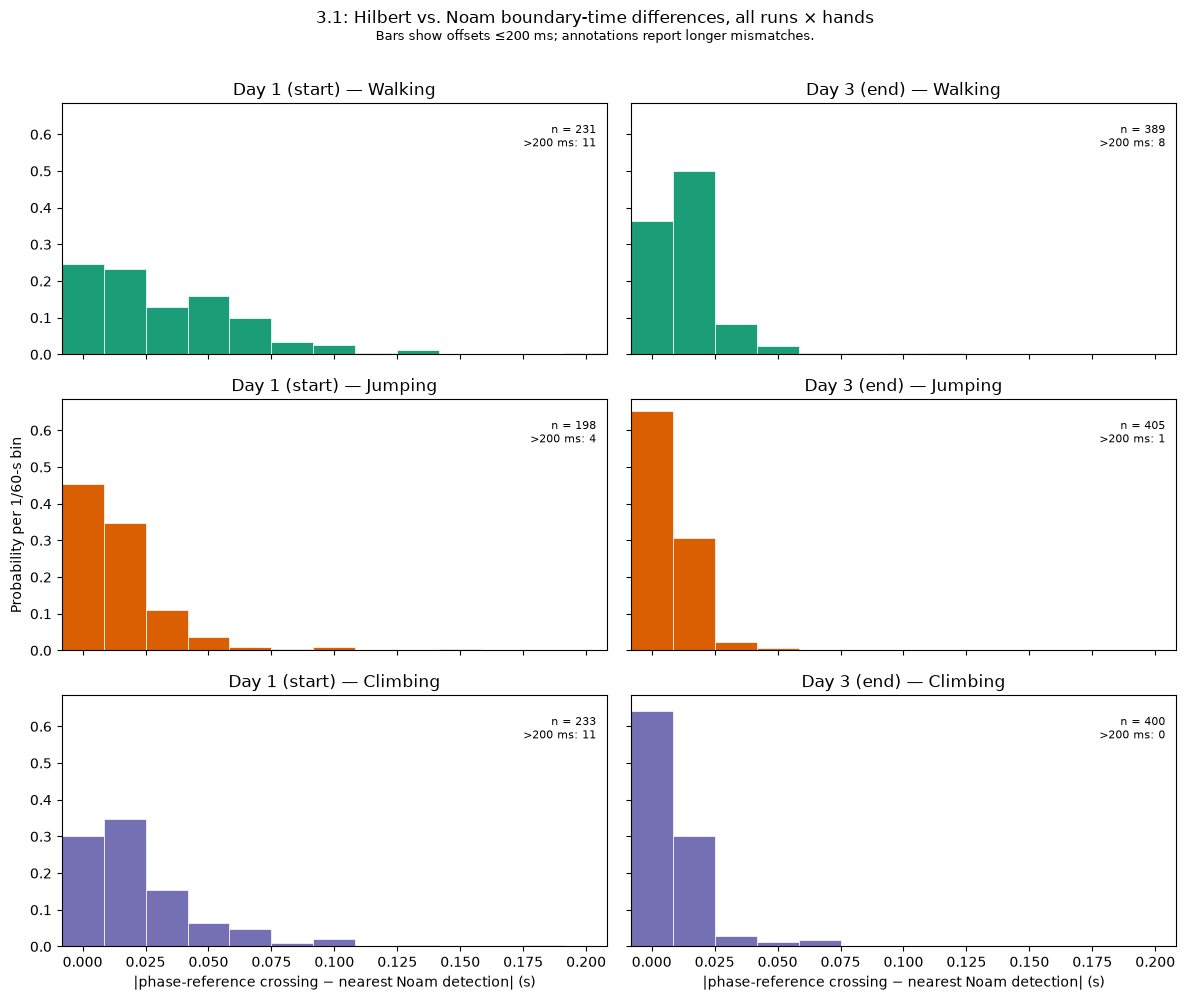

In [20]:
skills = ["walk", "jump", "climb"]
days = [1, 3]
# One-frame-wide bins preserve the timing resolution of the 60-Hz recordings.
bin_width = 1 / FS_HZ
display_max_sec = 0.20  # 12 frames; longer mismatches are reported in each panel.
bins = np.arange(-bin_width / 2, display_max_sec + 1.5 * bin_width, bin_width)

fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True, sharey=True)
for row_idx, skill in enumerate(skills):
    for col_idx, day in enumerate(days):
        ax = axes[row_idx, col_idx]
        condition = offsets_df[(offsets_df["skill"] == skill) & (offsets_df["day"] == day)]
        vals = condition["offset_sec"].to_numpy()
        part = condition["part"].iloc[0] if not condition.empty else CYCLE_PARAMS["day_part_map"][day]
        if len(vals):
            shown = vals[vals <= display_max_sec]
            ax.hist(shown, bins=bins, weights=np.full(len(shown), 1 / len(vals)),
                    color=P.SKILL_COLORS[skill], edgecolor="white", linewidth=0.5)
            tail_count = len(vals) - len(shown)
            ax.text(0.98, 0.92, f"n = {len(vals)}\n>200 ms: {tail_count}", transform=ax.transAxes,
                    ha="right", va="top", fontsize=8)
        else:
            ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"Day {day} ({P.PART_LABELS[part]}) — {P.SKILL_LABELS[skill]}")
        ax.set_xlim(bins[0], bins[-1])

for ax in axes[-1, :]:
    ax.set_xlabel("|phase-reference crossing − nearest Noam detection| (s)")
axes[1, 0].set_ylabel("Probability per 1/60-s bin")
fig.suptitle("3.1: Hilbert vs. Noam boundary-time differences, all runs × hands", y=0.995)
fig.text(0.5, 0.965, "Bars show offsets ≤200 ms; annotations report longer mismatches.", ha="center", fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.97))
P.save_figure(fig, "stage3_hilbert_vs_noam_boundary_offset")
plt.show()


### Detection traces for the six primary conditions

Each panel is the longest block for one day × skill condition. The raw
hand-Y-relative-to-root traces are robustly scaled and vertically offset so
both hands are readable in the same panel. Vertical lines span the matching
hand's trace lane: orange marks Noam's detections and blue marks our
phase-reference crossings.


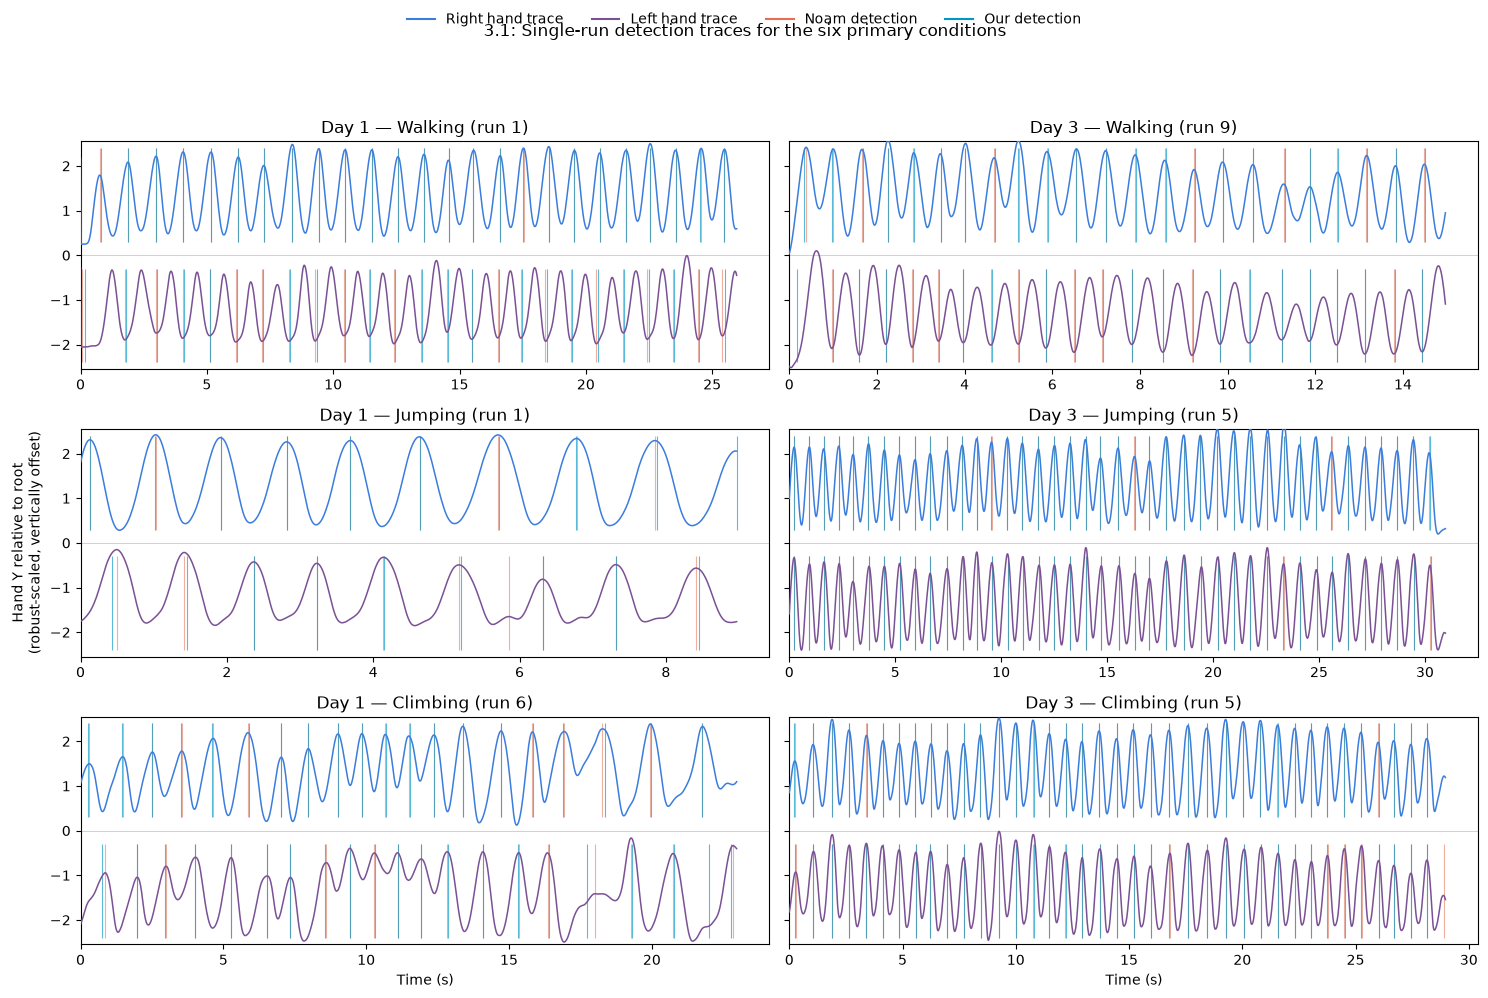

In [21]:
from matplotlib.lines import Line2D

TRACE_HAND_COLORS = {"r_hand": "#3b7ddd", "l_hand": "#7a5195"}
NOAM_DETECTION_COLOR = "#e76f51"
OUR_DETECTION_COLOR = "#0096c7"
TRACE_OFFSETS = {"r_hand": 1.35, "l_hand": -1.35}


def display_trace(raw, offset):
    """Robustly scale one hand, then put it in its own vertical lane."""
    raw = np.asarray(raw, dtype=float)
    center = np.nanmedian(raw)
    scale = np.nanpercentile(np.abs(raw - center), 95)
    scale = scale if np.isfinite(scale) and scale > 0 else 1.0
    return (raw - center) / scale + offset


trace_rows = (RUNS_DF.sort_values("run_duration_sec", ascending=False)
              .groupby(["day", "part", "skill"], as_index=False).first())
trace_lookup = {(row.day, row.skill): row for _, row in trace_rows.iterrows()}

fig, axes = plt.subplots(3, 2, figsize=(15, 10), sharey=True)
for row_idx, skill in enumerate(["walk", "jump", "climb"]):
    for col_idx, day in enumerate([1, 3]):
        ax = axes[row_idx, col_idx]
        row = trace_lookup.get((day, skill))
        if row is None:
            ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
            continue

        plotted = False
        for hand in ["r_hand", "l_hand"]:
            key = ("002", row.day, row.part, row.skill, row.source_file, row.movement_run_id, hand)
            if key not in PCA_CACHE:
                continue
            raw = raw_signal_for_run("002", row.day, row.part, row.skill, row.movement_run_id, hand)
            time_s = np.arange(len(raw)) / FS_HZ
            offset = TRACE_OFFSETS[hand]
            ax.plot(time_s, display_trace(raw, offset), color=TRACE_HAND_COLORS[hand], lw=1.1,
                    label=P.HAND_LABELS[hand], zorder=3)

            _, _, _, noam_events, _, _ = extract_cycles_from_signal(raw, skill, hand, CYCLE_PARAMS)
            our_events = phase_detection_indices(PCA_CACHE[key]["samples"]["phase"].to_numpy(),
                                                phase_reference(skill, hand))
            # Keep each hand's method lines in that hand's lane, behind its trace.
            ax.vlines(noam_events / FS_HZ, offset - 1.05, offset + 1.05, color=NOAM_DETECTION_COLOR,
                      lw=0.8, alpha=0.55, zorder=1)
            ax.vlines(our_events / FS_HZ, offset - 1.05, offset + 1.05, color=OUR_DETECTION_COLOR,
                      lw=0.8, alpha=0.65, zorder=2)
            plotted = True

        ax.axhline(0, color="0.82", lw=0.7, zorder=0)
        ax.set_ylim(-2.55, 2.55)
        ax.set_title(f"Day {day} — {P.SKILL_LABELS[skill]} (run {row.movement_run_id})")
        if plotted:
            ax.set_xlim(left=0)

for ax in axes[-1, :]:
    ax.set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Hand Y relative to root\n(robust-scaled, vertically offset)")

legend_handles = [
    Line2D([0], [0], color=TRACE_HAND_COLORS["r_hand"], lw=1.5, label="Right hand trace"),
    Line2D([0], [0], color=TRACE_HAND_COLORS["l_hand"], lw=1.5, label="Left hand trace"),
    Line2D([0], [0], color=NOAM_DETECTION_COLOR, lw=1.5, label="Noam detection"),
    Line2D([0], [0], color=OUR_DETECTION_COLOR, lw=1.5, label="Our detection"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=4, frameon=False)
fig.suptitle("3.1: Single-run detection traces for the six primary conditions", y=0.98)
fig.tight_layout(rect=(0, 0, 1, 0.93))
P.save_figure(fig, "stage3_single_run_detection_traces")
plt.show()


### Largest detection discrepancies: three-cycle views

For every skill and day/block, the three largest absolute differences between
an actual phase/PCA crossing and its nearest Noam detection are selected. Each
selection anchors a three-cycle view from that same run. Both hands are shown:
the triggering hand is noted in the row annotation, while the other hand is
aligned to its nearest phase/PCA crossing at the same time.


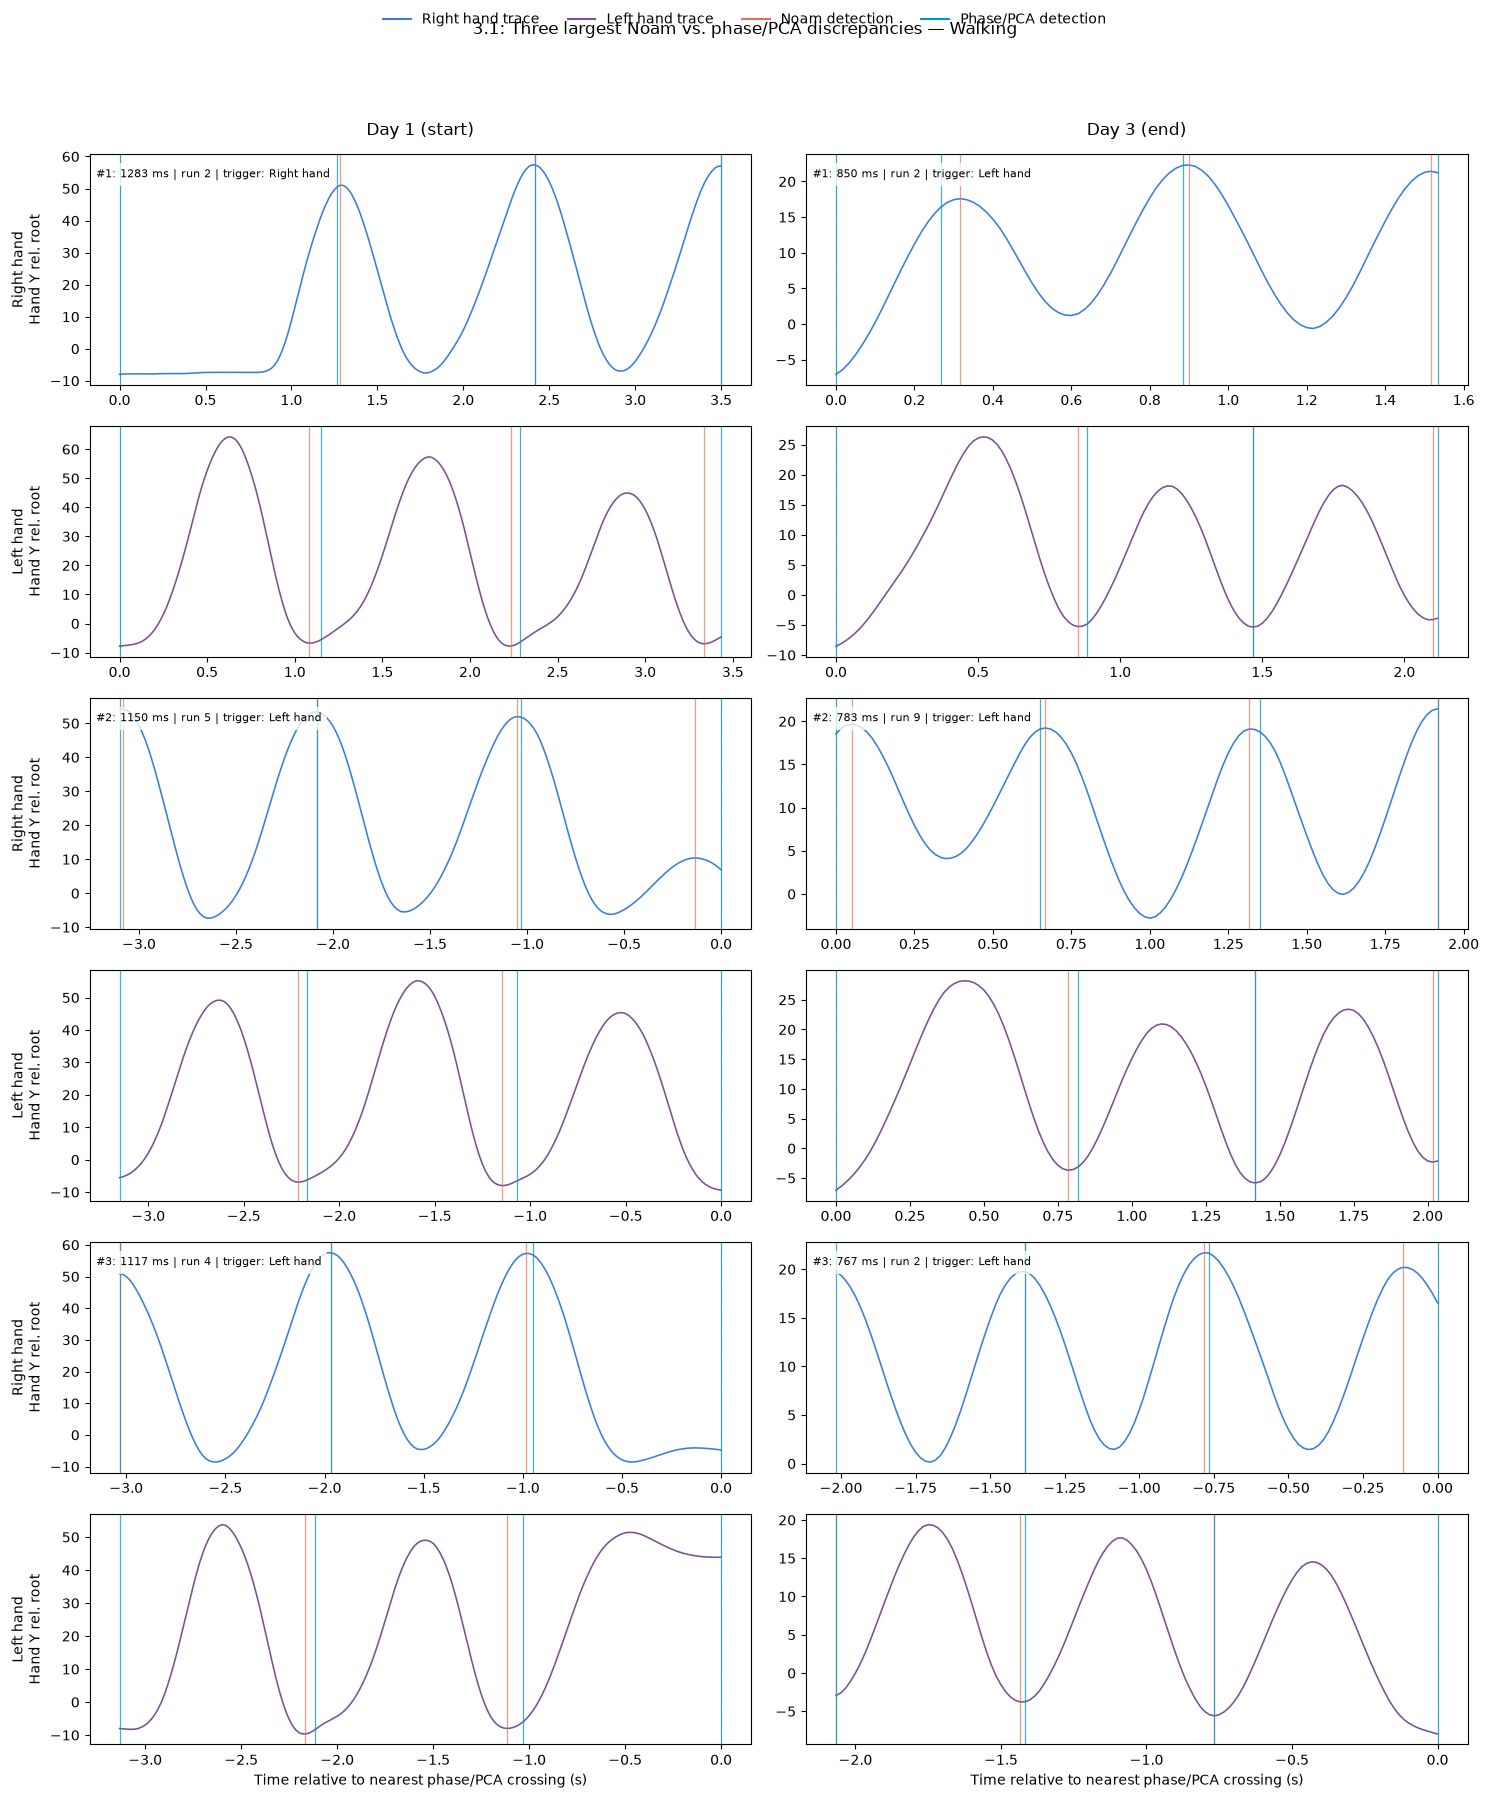

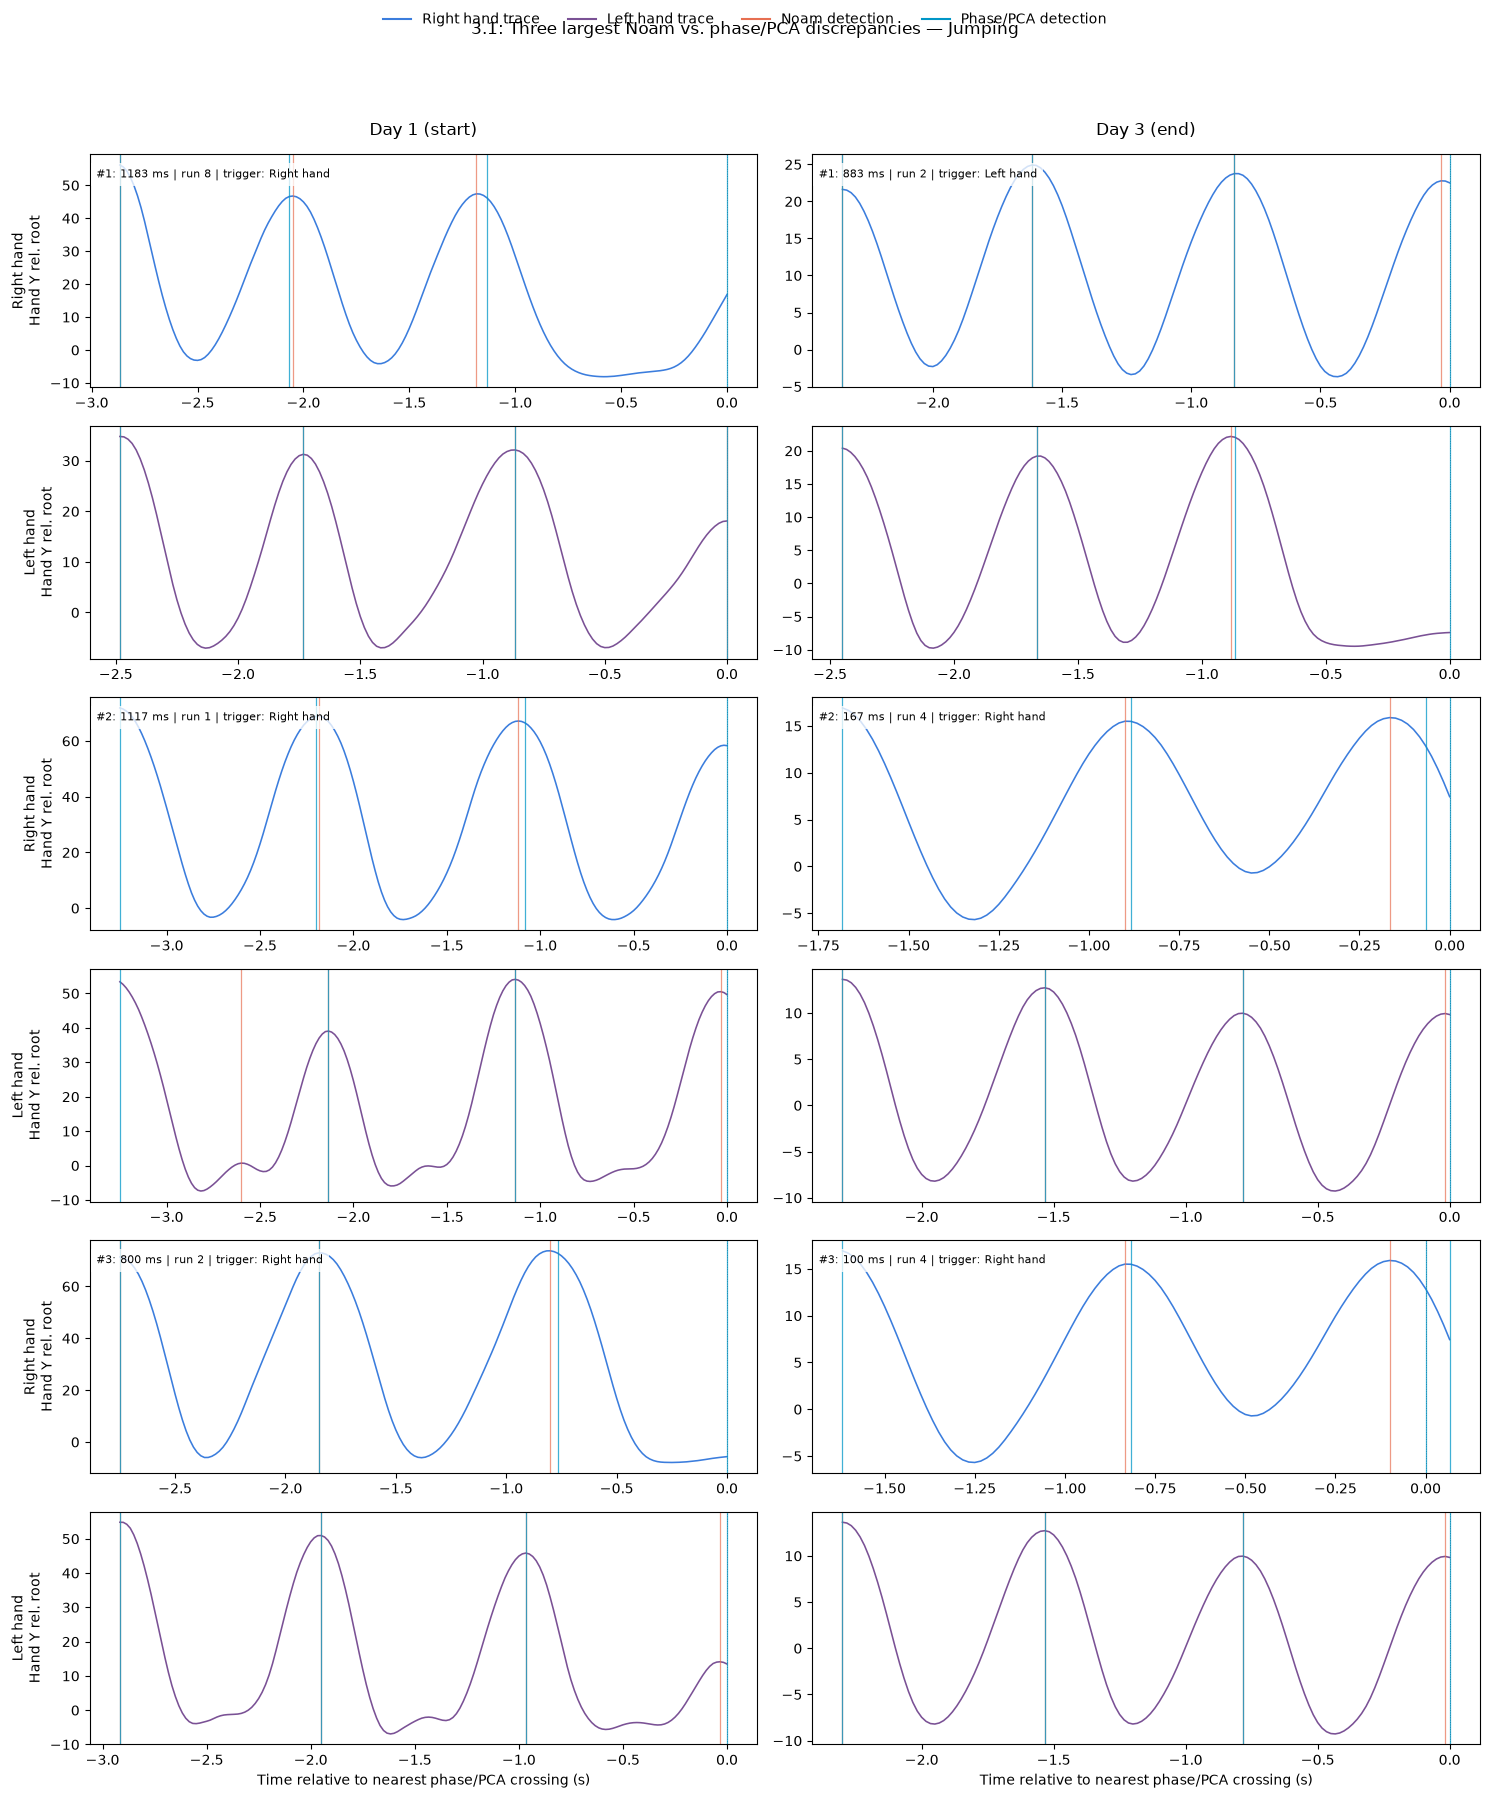

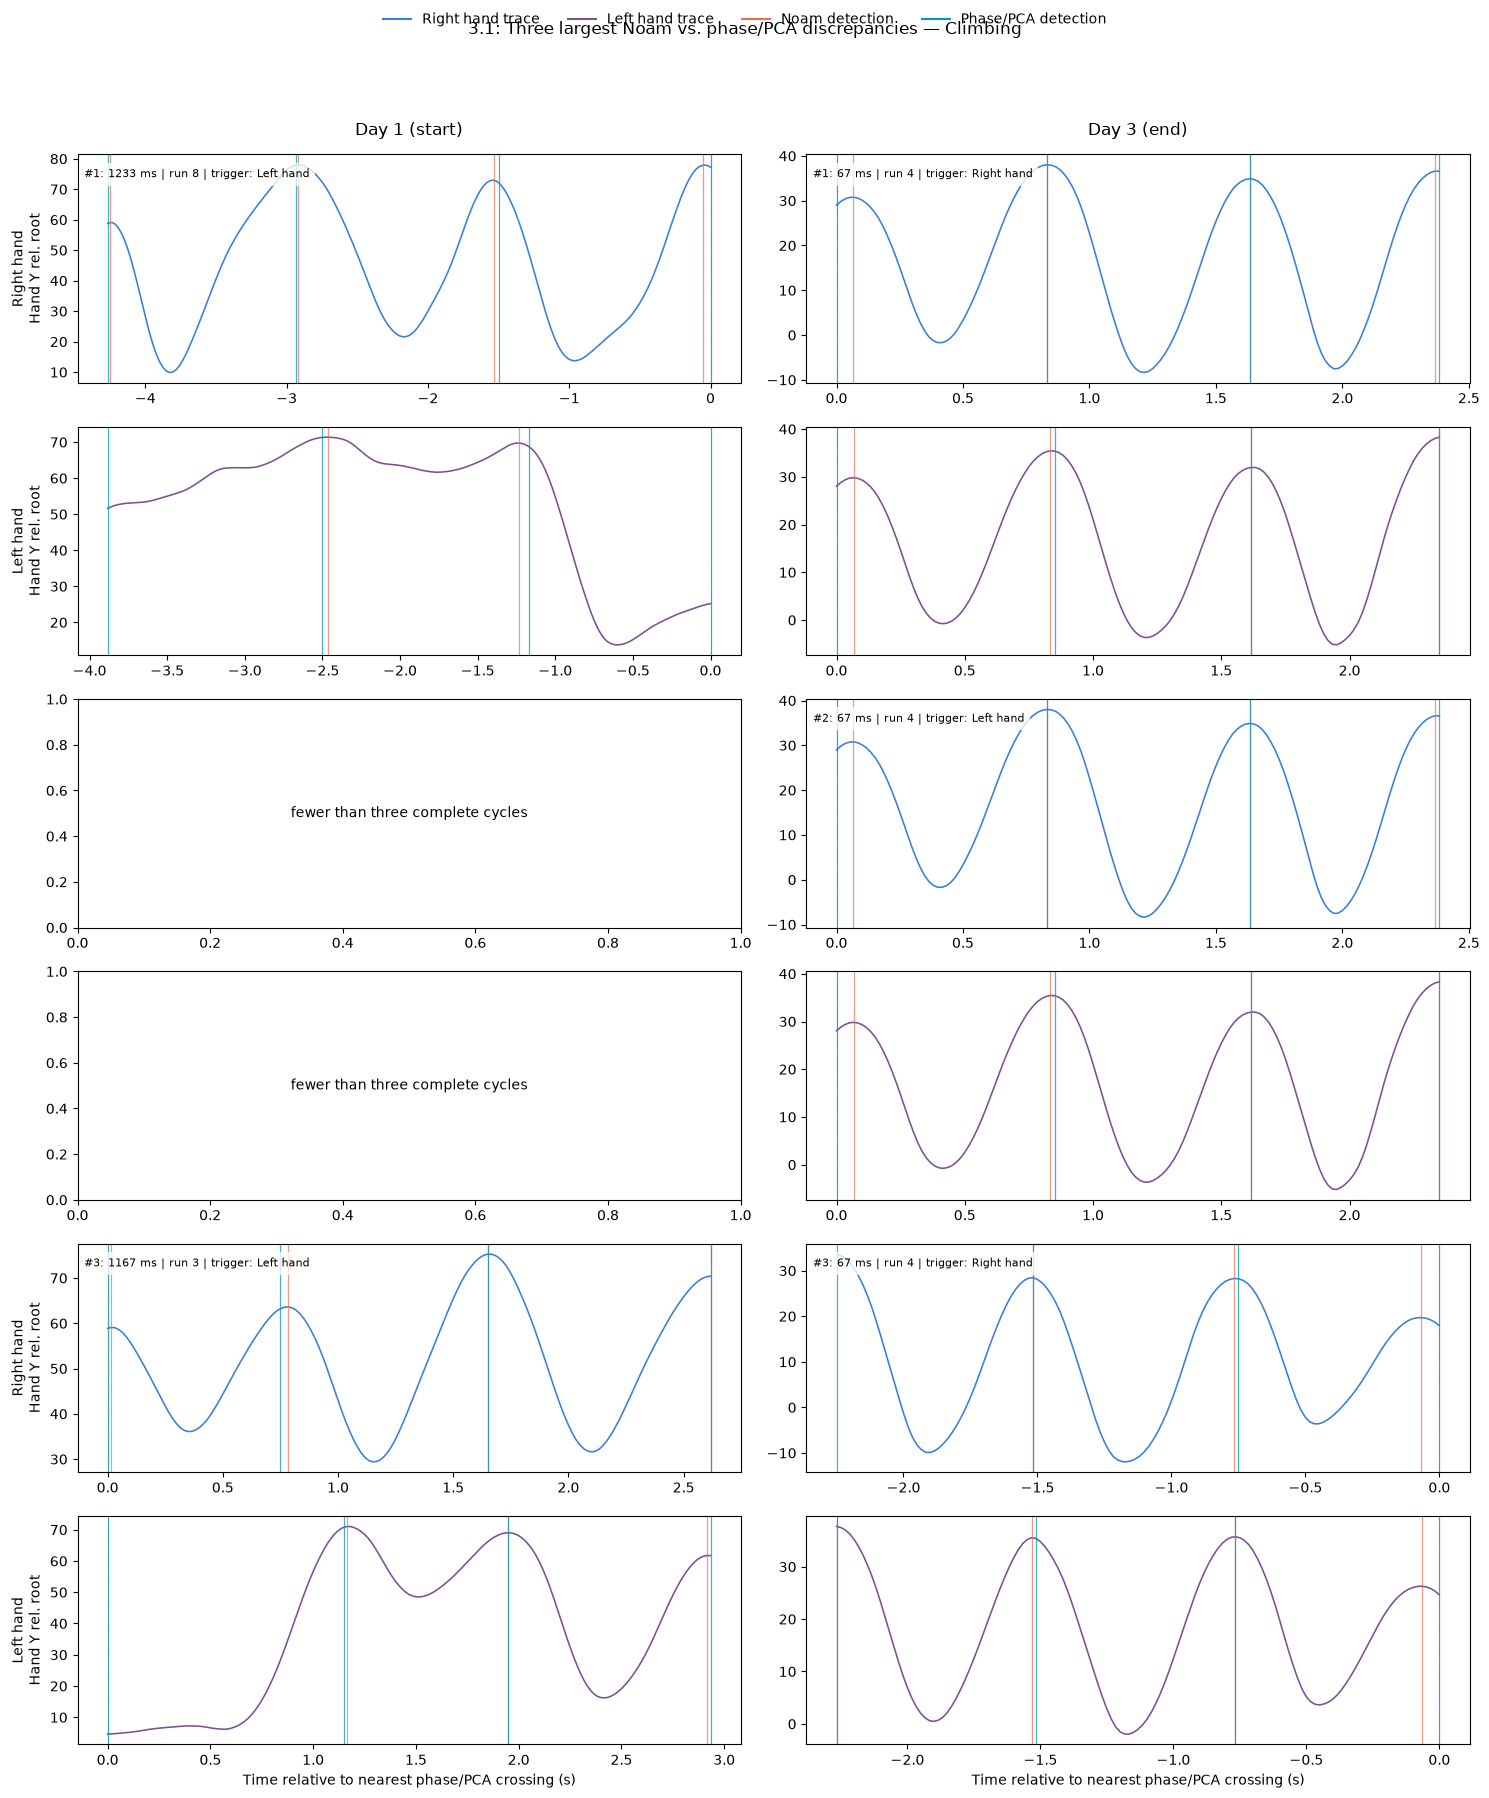

In [22]:
from matplotlib.lines import Line2D

TRACE_HAND_COLORS = {"r_hand": "#3b7ddd", "l_hand": "#7a5195"}
NOAM_DETECTION_COLOR = "#e76f51"
OUR_DETECTION_COLOR = "#0096c7"


def three_cycle_window(events, center_idx, n_cycles=3):
    """Return a complete n-cycle window centered as closely as possible on center_idx."""
    events = np.asarray(events, dtype=int)
    if len(events) < n_cycles + 1:
        return None
    center_pos = int(np.argmin(np.abs(events - center_idx)))
    start_pos = min(max(center_pos - 1, 0), len(events) - (n_cycles + 1))
    return int(events[start_pos]), int(events[start_pos + n_cycles]), int(events[center_pos])


worst_discrepancies = (discrepancies_df.sort_values("offset_sec", ascending=False)
                       .groupby(["day", "part", "skill"], group_keys=False).head(3))

for skill in ["walk", "jump", "climb"]:
    fig, axes = plt.subplots(6, 2, figsize=(15, 18), squeeze=False)
    for col_idx, (day, part) in enumerate([(1, "s"), (3, "e")]):
        selected = (worst_discrepancies[(worst_discrepancies["skill"] == skill)
                                       & (worst_discrepancies["day"] == day)
                                       & (worst_discrepancies["part"] == part)]
                    .sort_values("offset_sec", ascending=False).reset_index(drop=True))
        axes[0, col_idx].set_title(f"Day {day} ({P.PART_LABELS[part]})", fontsize=12, pad=14)

        for rank in range(3):
            for hand_idx, hand in enumerate(["r_hand", "l_hand"]):
                ax = axes[2 * rank + hand_idx, col_idx]
                if rank >= len(selected):
                    ax.text(0.5, 0.5, "no discrepancy", ha="center", va="center", transform=ax.transAxes)
                    continue

                discrepancy = selected.iloc[rank]
                key = ("002", discrepancy.day, discrepancy.part, discrepancy.skill,
                       discrepancy.source_file, discrepancy.run_id, hand)
                if key not in PCA_CACHE:
                    ax.text(0.5, 0.5, "hand not cached", ha="center", va="center", transform=ax.transAxes)
                    continue

                raw = raw_signal_for_run("002", discrepancy.day, discrepancy.part, discrepancy.skill,
                                         discrepancy.run_id, hand)
                _, _, _, noam_events, _, _ = extract_cycles_from_signal(raw, skill, hand, CYCLE_PARAMS)
                our_events = phase_detection_indices(PCA_CACHE[key]["samples"]["phase"].to_numpy(),
                                                    phase_reference(skill, hand))
                target_idx = int(round(discrepancy.our_event_time_sec * FS_HZ))
                window = three_cycle_window(our_events, target_idx)
                if window is None:
                    ax.text(0.5, 0.5, "fewer than three complete cycles", ha="center", va="center", transform=ax.transAxes)
                    continue

                start_idx, stop_idx, center_idx = window
                local_time = (np.arange(start_idx, stop_idx + 1) - center_idx) / FS_HZ
                ax.plot(local_time, raw[start_idx:stop_idx + 1], color=TRACE_HAND_COLORS[hand], lw=1.15)
                for event_idx in noam_events[(noam_events >= start_idx) & (noam_events <= stop_idx)]:
                    ax.axvline((event_idx - center_idx) / FS_HZ, color=NOAM_DETECTION_COLOR, lw=0.9, alpha=0.7)
                for event_idx in our_events[(our_events >= start_idx) & (our_events <= stop_idx)]:
                    ax.axvline((event_idx - center_idx) / FS_HZ, color=OUR_DETECTION_COLOR, lw=0.9, alpha=0.75)
                ax.axvline(0, color="0.35", lw=0.65, ls=":", zorder=0)

                if col_idx == 0:
                    ax.set_ylabel(f"{P.HAND_LABELS[hand]}\nHand Y rel. root")
                if hand_idx == 0:
                    ax.text(0.01, 0.94,
                            f"#{rank + 1}: {discrepancy.offset_sec * 1000:.0f} ms | run {discrepancy.run_id} | trigger: {P.HAND_LABELS[discrepancy.hand]}",
                            transform=ax.transAxes, ha="left", va="top", fontsize=8,
                            bbox=dict(facecolor="white", alpha=0.78, edgecolor="none"))

    for ax in axes[-1, :]:
        ax.set_xlabel("Time relative to nearest phase/PCA crossing (s)")
    fig.legend(handles=[
        Line2D([0], [0], color=TRACE_HAND_COLORS["r_hand"], lw=1.5, label="Right hand trace"),
        Line2D([0], [0], color=TRACE_HAND_COLORS["l_hand"], lw=1.5, label="Left hand trace"),
        Line2D([0], [0], color=NOAM_DETECTION_COLOR, lw=1.5, label="Noam detection"),
        Line2D([0], [0], color=OUR_DETECTION_COLOR, lw=1.5, label="Phase/PCA detection"),
    ], loc="upper center", ncol=4, frameon=False)
    fig.suptitle(f"3.1: Three largest Noam vs. phase/PCA discrepancies — {P.SKILL_LABELS[skill]}", y=0.99)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    P.save_figure(fig, f"stage3_{skill}_largest_detection_discrepancies")
    plt.show()


## 3.2 -- Side-by-side: cycle count, duration, and mean-cycle shape

For each of the 6 primary (longest-per-condition) blocks, run both
detectors on the same raw hand-Y-relative-to-root signal. Noam's event
boundaries and our phase-anchored boundaries slice that raw signal into
separate cycles, which are then resampled before averaging. This is a raw
vs. raw comparison: any difference between the curves therefore reflects
the detection boundaries (including detection jitter), rather than PCA
reconstruction.


In [23]:
primary_rows = (RUNS_DF.sort_values("run_duration_sec", ascending=False)
                .groupby(["day", "part", "skill"], as_index=False).first())

def resample_raw_cycle(segment, n_points=100):
    """Resample a finite raw cycle to a common time base."""
    segment = np.asarray(segment, dtype=float)
    if len(segment) < 2 or not np.isfinite(segment).all():
        return None
    return np.interp(np.linspace(0, 1, n_points), np.linspace(0, 1, len(segment)), segment)


comparison_rows = []
mean_shapes = {}  # (day, part, skill, hand) -> {"noam": arr, "ours": arr}

for _, prow in primary_rows.iterrows():
    day, part, skill, run_id, source_file = prow.day, prow.part, prow.skill, prow.movement_run_id, prow.source_file
    for hand in ["r_hand", "l_hand"]:
        key = ("002", day, part, skill, source_file, run_id, hand)
        if key not in PCA_CACHE:
            continue
        entry = PCA_CACHE[key]
        samples = entry["samples"]

        phase_arr = samples["phase"].to_numpy()
        ref = phase_reference(skill, hand)
        our_windows = phase_anchored_windows(phase_arr, ref, min_samples=5)
        if len(our_windows) < 2:
            continue
        our_durations = [(e - s) / FS_HZ for s, e in our_windows]

        raw = raw_signal_for_run("002", day, part, skill, run_id, hand)
        noam_cycles, _, _, _, _, _ = extract_cycles_from_signal(raw, skill, hand, CYCLE_PARAMS)

        comparison_rows.append({
            "day": day, "part": part, "skill": skill, "hand": hand,
            "n_cycles_ours": len(our_windows), "n_cycles_noam": len(noam_cycles),
            "median_duration_ours": float(np.median(our_durations)),
            "median_duration_noam": (np.median([c["duration_sec"] for c in noam_cycles])
                                      if noam_cycles else np.nan),
        })

        noam_norm_cycles = [resample_raw_cycle(c["y_cycle_raw"]) for c in noam_cycles]
        noam_norm_cycles = [cycle for cycle in noam_norm_cycles if cycle is not None]
        noam_mean = np.nanmean(np.vstack(noam_norm_cycles), axis=0) if noam_norm_cycles else None

        our_norm_cycles = [resample_raw_cycle(raw[s:e]) for s, e in our_windows]
        our_norm_cycles = [cycle for cycle in our_norm_cycles if cycle is not None]
        our_mean = np.nanmean(np.vstack(our_norm_cycles), axis=0) if our_norm_cycles else None

        mean_shapes[(day, part, skill, hand)] = {"noam": noam_mean, "ours": our_mean}

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,day,part,skill,hand,n_cycles_ours,n_cycles_noam,median_duration_ours,median_duration_noam
0,1,s,climb,r_hand,21,18,1.050000,1.066667
1,1,s,climb,l_hand,22,18,1.058333,1.066667
2,1,s,jump,r_hand,10,8,0.925000,0.925000
3,1,s,jump,l_hand,10,9,0.958333,0.916667
4,1,s,walk,r_hand,26,24,1.025000,1.033333
5,1,s,walk,l_hand,26,24,1.016667,1.033333
6,3,e,climb,r_hand,39,37,0.750000,0.750000
7,3,e,climb,l_hand,39,38,0.750000,0.750000
8,3,e,jump,r_hand,42,40,0.750000,0.750000
9,3,e,jump,l_hand,42,40,0.750000,0.758333


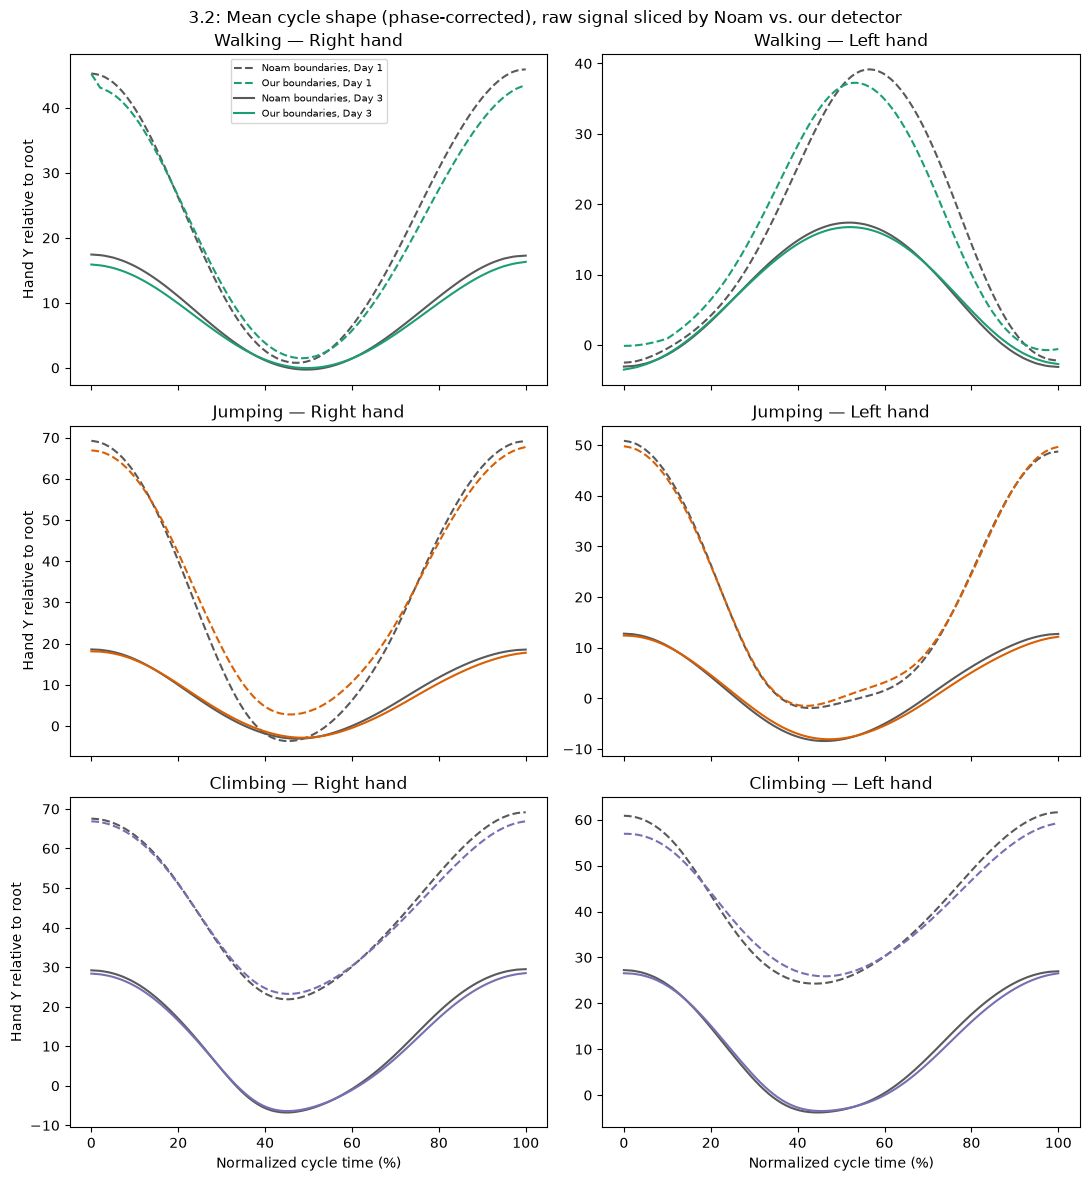

In [24]:
fig, axes = plt.subplots(3, 2, figsize=(11, 12), sharex=True)
for i, skill in enumerate(["walk", "jump", "climb"]):
    for j, hand in enumerate(["r_hand", "l_hand"]):
        ax = axes[i, j]
        any_plotted = False
        for (day, part, sk, hd), shapes in mean_shapes.items():
            if sk != skill or hd != hand:
                continue
            t = np.linspace(0, 100, 100)
            if shapes["noam"] is not None:
                ax.plot(t, shapes["noam"], color="0.35", linestyle=P.DAY_LINESTYLES[day],
                        label=f"Noam boundaries, Day {day}")
                any_plotted = True
            if shapes["ours"] is not None:
                ax.plot(t, shapes["ours"], color=P.SKILL_COLORS[skill], linestyle=P.DAY_LINESTYLES[day],
                        label=f"Our boundaries, Day {day}")
                any_plotted = True
        ax.set_title(f"{P.SKILL_LABELS[skill]} — {P.HAND_LABELS[hand]}")
        if not any_plotted:
            ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
        if i == 0 and j == 0:
            ax.legend(fontsize=7)
axes[-1, 0].set_xlabel("Normalized cycle time (%)")
axes[-1, 1].set_xlabel("Normalized cycle time (%)")
for ax in axes[:, 0]:
    ax.set_ylabel("Hand Y relative to root")
fig.suptitle("3.2: Mean cycle shape (phase-corrected), raw signal sliced by Noam vs. our detector")
fig.tight_layout()
P.save_figure(fig, "stage3_mean_cycle_shape_comparison")
plt.show()


## Summary numbers for PROGRESS.md

In [25]:
print("=== 3.1 boundary offsets by skill (seconds) ===")
print(offsets_df.groupby("skill")["offset_sec"].describe()[["50%", "25%", "75%", "count"]])
print()
print("=== 3.1 phase-warning rate by skill ===")
print(warn_df.groupby("skill")["has_phase_warning"].mean())
print()
print("=== 3.2 cycle count / duration comparison ===")
print(comparison_df.to_string(index=False))


=== 3.1 boundary offsets by skill (seconds) ===
            50%  25%       75%  count
skill                                
climb  0.000000  0.0  0.016667  633.0
jump   0.000000  0.0  0.016667  603.0
walk   0.016667  0.0  0.033333  620.0

=== 3.1 phase-warning rate by skill ===
skill
climb    0.000
jump     0.025
walk     0.000
Name: has_phase_warning, dtype: float64

=== 3.2 cycle count / duration comparison ===
 day part skill   hand  n_cycles_ours  n_cycles_noam  median_duration_ours  median_duration_noam
   1    s climb r_hand             21             18              1.050000              1.066667
   1    s climb l_hand             22             18              1.058333              1.066667
   1    s  jump r_hand             10              8              0.925000              0.925000
   1    s  jump l_hand             10              9              0.958333              0.916667
   1    s  walk r_hand             26             24              1.025000              1.033333
 